In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [2]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# np.set_printoptions(threshold=np.inf, linewidth=400, precision=2)

# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

In [3]:
# 全局变量：保存上一帧数据，用于实时计算
prev_frame = None 

In [4]:
# ===================== 数组自动网格输出（你要的格式） =====================
def auto_print(data, title):
    print(f"\n{'='*60}")
    print(f"📌 {title} | 形状 = {data.shape}")
    vec = data[0]
    n = len(vec)
    
    if n == 84:
        rows, cols = 7, 12
    elif n == 77:
        rows, cols = 7, 11
    elif n == 72:
        rows, cols = 6, 12
    elif n == 66:
        rows, cols = 6, 11
    else:
        print(vec)
        return
    
    print(f"✅ 输出格式：{rows}行 × {cols}列")
    print("-" * (cols * 7))
    grid = vec.reshape(rows, cols)
    for i in range(rows):
        print(f"行{i+1:2d} | " + " ".join(f"{v:6.1f}" for v in grid[i]))

# 打印全部行的矩阵
def print_full_matrix(data, title, rows, cols):
    print(f"\n{'='*60}")
    print(f"📌 {title} | 全部行 | {rows}×{cols}")
    for i in range(data.shape[0]):
        print(f"\n--- 第 {i+1} 行 ---")
        grid = data[i].reshape(rows, cols)
        for r in range(rows):
            print(f"行{r+1:2d} | " + " ".join(f"{v:6.1f}" for v in grid[r]))

In [5]:
# ===================== 基线扣除 + 找安全的最大ADC列 =====================
global first_frame
first_frame = None

def subtract_baseline(current_frame):
    global first_frame
    current_frame = np.array(current_frame, dtype=np.float32).flatten()
    
    if first_frame is None:
        first_frame = current_frame.copy()
    
    # 基线扣除
    diff_frame = current_frame - first_frame
    abs_diff = np.abs(diff_frame)
    
    # ===================== 核心：从大到小找【安全列】=====================
    # 按绝对值从大到小排序
    candidate_cols = np.argsort(-abs_diff)
    
    best_col = None
    for col in candidate_cols:
        # 同时满足：左右不越界(列差分) + 上下7不越界(行差分)
        if (col - 1 >= 0) and (col + 1 < len(diff_frame)) and \
           (col - 7 >= 0) and (col + 7 < len(diff_frame)):
            best_col = col
            break  # 找到第一个满足条件的，立刻停止
    
    # 极端情况兜底
    if best_col is None:
        best_col = 42  # 中间位置
    
    # 最终输出：diff_frame + 安全的最佳列
    return diff_frame, abs_diff[best_col], best_col

In [6]:
# ===================== 2. 计算 diff_adjacent (12*6,列差分) =====================
def compute_diff_adjacent(frame, max_col):
    frame = np.array(frame)
    if max_col - 1 < 0 or max_col + 1 >= len(frame):
        return 0.0
    diff = frame[max_col + 1] - frame[max_col - 1]
    return np.array(diff)


In [7]:
# -------------------- 3. 计算 diff_7step (11*7,行差分) --------------------
def compute_diff_7step(frame, max_col):
    frame = np.array(frame)
    if max_col - 7 < 0 or max_col + 7 >= len(frame):
        return 0.0
    diff = frame[max_col + 7] - frame[max_col - 7]
    return np.array(diff)


In [8]:
# -------------------- 4. 计算ADC角度 --------------------
def compute_gradient_angle(x_diff, y_diff):
    """
    输入：
      x_diff = compute_diff_adjacent 返回值（横向差分：右-左）
      y_diff = compute_diff_7step 返回值（纵向差分：上7-下7）
    输出：
      0~360° 角度
    """
    epsilon = 1e-8
    
    # 直接计算方向角
    angle = np.degrees(np.arctan2(-y_diff, -x_diff + epsilon))
    
    # 转为 0~360°
    if angle < 0:
        angle += 360
        
    return angle

In [9]:
# -------------------- 5. 计算Force角度 --------------------
def compute_force_angle(Fx, Fy):
    import numpy as np
    epsilon = 1e-8
    angle = np.degrees(np.arctan2(Fy, Fx + epsilon))
    angle = angle + 360 if angle < 0 else angle
    return angle

In [10]:
# ================================== 主程序 ==================================
# 1. 读取数据
df = pd.read_csv('/home/qcy/Project/data/2.PZT_tangential/weight/test/data_2.csv')
data_original = df.iloc[:, 2:86].values

force_Fx = df.iloc[:, 86].values
force_Fy = df.iloc[:, 87].values

# 2. 初始化存储数组
data_diff = np.zeros_like(data_original)          # 基线扣除结果 (N,84)
diff_adjacent_list = []                           # 列差分结果 (N,72)
diff_adjacent7_list = []                          # 行差分结果 (N,77)
ADC_angle_list = []                               # 角度结果 (N,66) 
force_angle_list = []                             # Force角度结果 (N,1) 
ADC_force_angle_list = []                         # ADC角度+Force角度结果 (N,67)   

max_adc_list = []                                 # 最大绝对值ADC (N,)
max_col_list = []                                 # 最大列号 (N,)

# 3. 主循环
for i in range(data_original.shape[0]):
    # -------------------- 步骤1：基线扣除 --------------------
    current_frame = data_original[i]
    diff_frame, max_adc, max_col = subtract_baseline(current_frame)
    data_diff[i] = diff_frame
    max_adc_list.append(max_adc)
    max_col_list.append(max_col)

    # -------------------- 步骤2：列差分 --------------------
    adj_frame_row = compute_diff_adjacent(diff_frame, max_col)
    diff_adjacent_list.append(adj_frame_row)

    # -------------------- 步骤3：行差分 --------------------
    adj_frame_col = compute_diff_7step(diff_frame, max_col)
    diff_adjacent7_list.append(adj_frame_col)

    # -------------------- 步骤4：计算ADC角度 --------------------
    angle = compute_gradient_angle(adj_frame_row, adj_frame_col)
    ADC_angle_list.append(angle)

    # -------------------- 步骤5：计算Force角度 --------------------   
    fx = force_Fx[i]
    fy = force_Fy[i]
    f_angle = compute_force_angle(fx, fy)
    force_angle_list.append(f_angle)

# 转成numpy数组
diff_adjacent = np.array(diff_adjacent_list)
diff_adjacent7 = np.array(diff_adjacent7_list)
gradient_angle = np.array(ADC_angle_list)
force_angle = np.array(force_angle_list)
max_adc_array = np.array(max_adc_list)
max_col_array = np.array(max_col_list)

In [11]:
# ===================== 打印输出 =====================
print(f"\n✅ data_original shape: {data_original.shape}")
print_full_matrix(data_original, "data_original", 12, 7)


✅ data_original shape: (321, 84)

📌 data_original | 全部行 | 12×7

--- 第 1 行 ---
行 1 |  320.0  173.0   99.0   93.0    7.0   72.0   30.0
行 2 |  109.0   85.0   53.0   48.0    7.0   32.0   16.0
行 3 |  117.0  119.0   69.0   72.0    7.0   53.0   30.0
行 4 |   57.0   71.0   45.0   45.0    7.0   34.0   24.0
行 5 |   73.0  125.0   72.0   85.0    7.0   96.0   68.0
行 6 |   46.0   71.0   53.0   66.0    7.0   85.0   49.0
行 7 |   30.0   59.0   34.0   34.0    7.0   34.0   38.0
行 8 |   35.0   99.0   40.0   45.0    7.0   45.0   90.0
行 9 |   21.0   54.0   26.0   24.0    7.0   18.0   33.0
行10 |   13.0   14.0   18.0   13.0    7.0    8.0    8.0
行11 |   27.0  122.0   34.0   34.0    7.0   34.0  146.0
行12 |   35.0  267.0   43.0   45.0    7.0   64.0  391.0

--- 第 2 行 ---
行 1 |  320.0  173.0   99.0   93.0    7.0   72.0   30.0
行 2 |  109.0   85.0   53.0   48.0    7.0   32.0   16.0
行 3 |  117.0  116.0   69.0   66.0    7.0   48.0   27.0
行 4 |   60.0   65.0   45.0   45.0    4.0   34.0   24.0
行 5 |   73.0  125.0   72.0

In [12]:
print(f"\n✅ data_diff 基线扣除 shape: {data_diff.shape}")
print_full_matrix(data_diff, "data_diff 基线扣除", 12, 7)


✅ data_diff 基线扣除 shape: (321, 84)

📌 data_diff 基线扣除 | 全部行 | 12×7

--- 第 1 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 4 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 5 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 6 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 7 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 8 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 9 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行10 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行11 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行12 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0

--- 第 2 行 ---
行 1 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 2 |    0.0    0.0    0.0    0.0    0.0    0.0    0.0
行 3 |    0.0   -3.0    0.0   -6.0    0.0   -5.0   -3.0
行 4 |    3.0   -6.0    0.0    0.0   -3.0    0.0    0.0
行 5 |    0.0    0.0    0

In [13]:
print(f"\n✅ MAX ADC shape: {max_adc_array.shape}")
print_full_matrix(max_adc_array, "max_adc ", 1, 1)
print(f"\n✅ MAX COL shape: {max_col_array.shape}")
print_full_matrix(max_col_array, "max_col ", 1, 1)



✅ MAX ADC shape: (321,)

📌 max_adc  | 全部行 | 1×1

--- 第 1 行 ---
行 1 |    0.0

--- 第 2 行 ---
行 1 |    8.0

--- 第 3 行 ---
行 1 |   13.0

--- 第 4 行 ---
行 1 |    9.0

--- 第 5 行 ---
行 1 |   23.0

--- 第 6 行 ---
行 1 |   25.0

--- 第 7 行 ---
行 1 |   23.0

--- 第 8 行 ---
行 1 |   14.0

--- 第 9 行 ---
行 1 |    6.0

--- 第 10 行 ---
行 1 |    6.0

--- 第 11 行 ---
行 1 |    6.0

--- 第 12 行 ---
行 1 |    6.0

--- 第 13 行 ---
行 1 |    8.0

--- 第 14 行 ---
行 1 |    8.0

--- 第 15 行 ---
行 1 |   14.0

--- 第 16 行 ---
行 1 |   11.0

--- 第 17 行 ---
行 1 |   11.0

--- 第 18 行 ---
行 1 |   17.0

--- 第 19 行 ---
行 1 |   14.0

--- 第 20 行 ---
行 1 |   14.0

--- 第 21 行 ---
行 1 |   14.0

--- 第 22 行 ---
行 1 |   23.0

--- 第 23 行 ---
行 1 |   14.0

--- 第 24 行 ---
行 1 |   17.0

--- 第 25 行 ---
行 1 |   17.0

--- 第 26 行 ---
行 1 |   17.0

--- 第 27 行 ---
行 1 |   17.0

--- 第 28 行 ---
行 1 |   20.0

--- 第 29 行 ---
行 1 |   14.0

--- 第 30 行 ---
行 1 |   11.0

--- 第 31 行 ---
行 1 |   11.0

--- 第 32 行 ---
行 1 |   14.0

--- 第 33 行 ---
行 1 |   25.0

--

In [14]:
print(f"✅ diff_adjacent 列差分 shape: {diff_adjacent.shape}")
print_full_matrix(diff_adjacent, "diff_adjacent 列差分", 1, 1)

✅ diff_adjacent 列差分 shape: (321,)

📌 diff_adjacent 列差分 | 全部行 | 1×1

--- 第 1 行 ---
行 1 |    0.0

--- 第 2 行 ---
行 1 |   -2.0

--- 第 3 行 ---
行 1 |   -8.0

--- 第 4 行 ---
行 1 |    5.0

--- 第 5 行 ---
行 1 |   -5.0

--- 第 6 行 ---
行 1 |   -3.0

--- 第 7 行 ---
行 1 |   -3.0

--- 第 8 行 ---
行 1 |   -3.0

--- 第 9 行 ---
行 1 |    0.0

--- 第 10 行 ---
行 1 |    2.0

--- 第 11 行 ---
行 1 |    0.0

--- 第 12 行 ---
行 1 |    0.0

--- 第 13 行 ---
行 1 |    0.0

--- 第 14 行 ---
行 1 |    0.0

--- 第 15 行 ---
行 1 |   -3.0

--- 第 16 行 ---
行 1 |    6.0

--- 第 17 行 ---
行 1 |    6.0

--- 第 18 行 ---
行 1 |   -3.0

--- 第 19 行 ---
行 1 |    3.0

--- 第 20 行 ---
行 1 |   -3.0

--- 第 21 行 ---
行 1 |   -3.0

--- 第 22 行 ---
行 1 |    0.0

--- 第 23 行 ---
行 1 |    0.0

--- 第 24 行 ---
行 1 |   -3.0

--- 第 25 行 ---
行 1 |   -3.0

--- 第 26 行 ---
行 1 |    0.0

--- 第 27 行 ---
行 1 |   -3.0

--- 第 28 行 ---
行 1 |   -3.0

--- 第 29 行 ---
行 1 |   -3.0

--- 第 30 行 ---
行 1 |    0.0

--- 第 31 行 ---
行 1 |    0.0

--- 第 32 行 ---
行 1 |   -5.0

--- 第 33 行 --

In [15]:
print(f"✅ diff_adjacent7 行差分 shape: {diff_adjacent7.shape}")
print_full_matrix(diff_adjacent7, "diff_adjacent7 行差分", 1, 1)

✅ diff_adjacent7 行差分 shape: (321,)

📌 diff_adjacent7 行差分 | 全部行 | 1×1

--- 第 1 行 ---
行 1 |    0.0

--- 第 2 行 ---
行 1 |    0.0

--- 第 3 行 ---
行 1 |    6.0

--- 第 4 行 ---
行 1 |    2.0

--- 第 5 行 ---
行 1 |   -3.0

--- 第 6 行 ---
行 1 |    0.0

--- 第 7 行 ---
行 1 |    3.0

--- 第 8 行 ---
行 1 |    0.0

--- 第 9 行 ---
行 1 |   -6.0

--- 第 10 行 ---
行 1 |   -6.0

--- 第 11 行 ---
行 1 |   -6.0

--- 第 12 行 ---
行 1 |   -6.0

--- 第 13 行 ---
行 1 |    2.0

--- 第 14 行 ---
行 1 |    2.0

--- 第 15 行 ---
行 1 |    0.0

--- 第 16 行 ---
行 1 |    0.0

--- 第 17 行 ---
行 1 |    0.0

--- 第 18 行 ---
行 1 |   -2.0

--- 第 19 行 ---
行 1 |    0.0

--- 第 20 行 ---
行 1 |    3.0

--- 第 21 行 ---
行 1 |    3.0

--- 第 22 行 ---
行 1 |   -3.0

--- 第 23 行 ---
行 1 |   -6.0

--- 第 24 行 ---
行 1 |   -6.0

--- 第 25 行 ---
行 1 |   -6.0

--- 第 26 行 ---
行 1 |    3.0

--- 第 27 行 ---
行 1 |   -3.0

--- 第 28 行 ---
行 1 |    3.0

--- 第 29 行 ---
行 1 |    8.0

--- 第 30 行 ---
行 1 |   -6.0

--- 第 31 行 ---
行 1 |   -3.0

--- 第 32 行 ---
行 1 |   -3.0

--- 第 33 行 

In [16]:
print(f"✅ gradient_angle ADC角度 shape: {gradient_angle.shape}")
print_full_matrix(gradient_angle, "gradient_angle ADC角度", 1, 1)

✅ gradient_angle ADC角度 shape: (321,)

📌 gradient_angle ADC角度 | 全部行 | 1×1

--- 第 1 行 ---
行 1 |   -0.0

--- 第 2 行 ---
行 1 |   -0.0

--- 第 3 行 ---
行 1 |  323.1

--- 第 4 行 ---
行 1 |  201.8

--- 第 5 行 ---
行 1 |   31.0

--- 第 6 行 ---
行 1 |   -0.0

--- 第 7 行 ---
行 1 |  315.0

--- 第 8 行 ---
行 1 |   -0.0

--- 第 9 行 ---
行 1 |   90.0

--- 第 10 行 ---
行 1 |  108.4

--- 第 11 行 ---
行 1 |   90.0

--- 第 12 行 ---
行 1 |   90.0

--- 第 13 行 ---
行 1 |  270.0

--- 第 14 行 ---
行 1 |  270.0

--- 第 15 行 ---
行 1 |   -0.0

--- 第 16 行 ---
行 1 |  180.0

--- 第 17 行 ---
行 1 |  180.0

--- 第 18 行 ---
行 1 |   33.7

--- 第 19 行 ---
行 1 |  180.0

--- 第 20 行 ---
行 1 |  315.0

--- 第 21 行 ---
行 1 |  315.0

--- 第 22 行 ---
行 1 |   90.0

--- 第 23 行 ---
行 1 |   90.0

--- 第 24 行 ---
行 1 |   63.4

--- 第 25 行 ---
行 1 |   63.4

--- 第 26 行 ---
行 1 |  270.0

--- 第 27 行 ---
行 1 |   45.0

--- 第 28 行 ---
行 1 |  315.0

--- 第 29 行 ---
行 1 |  290.6

--- 第 30 行 ---
行 1 |   90.0

--- 第 31 行 ---
行 1 |   90.0

--- 第 32 行 ---
行 1 |   31.0

--- 第 3

In [17]:
print(f"✅ force_angle Force角度 shape: {force_angle.shape}")
print_full_matrix(force_angle, "force_angle Force角度", 1, 1)

✅ force_angle Force角度 shape: (321,)

📌 force_angle Force角度 | 全部行 | 1×1

--- 第 1 行 ---
行 1 |  270.0

--- 第 2 行 ---
行 1 |  256.0

--- 第 3 行 ---
行 1 |  248.2

--- 第 4 行 ---
行 1 |  254.1

--- 第 5 行 ---
行 1 |  248.2

--- 第 6 行 ---
行 1 |  248.2

--- 第 7 行 ---
行 1 |  256.0

--- 第 8 行 ---
行 1 |  258.7

--- 第 9 行 ---
行 1 |  246.8

--- 第 10 行 ---
行 1 |  254.1

--- 第 11 行 ---
行 1 |  257.5

--- 第 12 行 ---
行 1 |  254.1

--- 第 13 行 ---
行 1 |  270.0

--- 第 14 行 ---
行 1 |  270.0

--- 第 15 行 ---
行 1 |  276.3

--- 第 16 行 ---
行 1 |  270.0

--- 第 17 行 ---
行 1 |  276.3

--- 第 18 行 ---
行 1 |  277.1

--- 第 19 行 ---
行 1 |  284.0

--- 第 20 行 ---
行 1 |  293.2

--- 第 21 行 ---
行 1 |  288.4

--- 第 22 行 ---
行 1 |  285.9

--- 第 23 行 ---
行 1 |  277.1

--- 第 24 行 ---
行 1 |  285.9

--- 第 25 行 ---
行 1 |  284.0

--- 第 26 行 ---
行 1 |  281.3

--- 第 27 行 ---
行 1 |  251.6

--- 第 28 行 ---
行 1 |  308.7

--- 第 29 行 ---
行 1 |  301.0

--- 第 30 行 ---
行 1 |  315.0

--- 第 31 行 ---
行 1 |  309.8

--- 第 32 行 ---
行 1 |  293.2

--- 第 33 

In [18]:
# ===================== 4. 拼接+保存 =====================
force_angle_array = np.array(force_angle_list)
force_angle = force_angle_array.reshape(-1, 1)

# ============== 修复：把 gradient_angle 变成二维 ==============
gradient_angle_2d = np.array(gradient_angle).reshape(-1, 1)  # 变成 (N,1)
ADC_force_angle = np.hstack([gradient_angle_2d, force_angle])  # 现在可以拼接

print(f"✅ force_angle ADC+Force shape: {ADC_force_angle.shape}")

# 1. 构造列名（现在只有 2 列：ADC角度 + Force角度）
columns = ["ADC_angle", "Force_angle"]

# 2. 转成标准二维表格（带表头）
df_result = pd.DataFrame(ADC_force_angle, columns=columns)

# 3. 控制台美观输出
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 9999)
print("✅ 带列名的完整二维表格：")
print(df_result)

# 4. 保存
save_path = "/home/qcy/Project/data/2.PZT_tangential/weight/pre/ADC_Force_angle_result.csv"
df_result.to_csv(save_path, index=False, float_format="%.2f")

print(f"\n✅ 文件已保存到：\n{save_path}")

✅ force_angle ADC+Force shape: (321, 2)
✅ 带列名的完整二维表格：
      ADC_angle  Force_angle
0     -0.000000   270.000029
1     -0.000000   255.963770
2    323.130096   248.198600
3    201.801422   254.054612
4     30.963757   248.198600
..          ...          ...
316  302.098938   323.130105
317  300.287964   323.130105
318  300.745361   326.309935
319  300.963745   315.000003
320  304.286865   320.710596

[321 rows x 2 columns]

✅ 文件已保存到：
/home/qcy/Project/data/2.PZT_tangential/weight/pre/ADC_Force_angle_result.csv


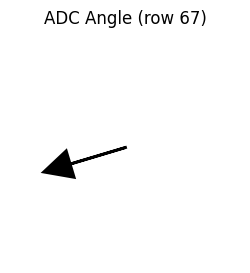

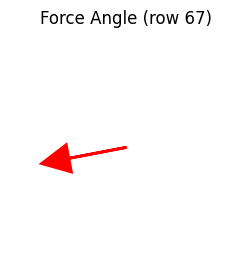

In [19]:
# ===================== 单ADC角度 + Force角度 · 两张对比 =====================
import matplotlib.pyplot as plt
import numpy as np

# 关闭多余输出
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "none"

row_idx = 66

# 现在只有 2 列：第0列=ADC角度，第1列=Force角度
adc_angle = ADC_force_angle[row_idx, 0]       # 只取 1 个角度
force_angle = ADC_force_angle[row_idx, 1]

# -------------------------- 图1：ADC 角度 --------------------------
fig1, ax1 = plt.subplots(1, 1, figsize=(3, 3))
theta = np.deg2rad(adc_angle)
ax1.arrow(0.5, 0.5, 0.25*np.cos(theta), 0.25*np.sin(theta),
         head_width=0.12, head_length=0.12, fc='k', ec='k', linewidth=2)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_aspect('equal')
ax1.axis('off')
plt.title(f"ADC Angle (row {row_idx+1})", fontsize=12)
plt.show()

# -------------------------- 图2：Force 角度 --------------------------
fig2, ax2 = plt.subplots(1, 1, figsize=(3, 3))
theta_f = np.deg2rad(force_angle)
ax2.arrow(0.5, 0.5, 0.25*np.cos(theta_f), 0.25*np.sin(theta_f),
          head_width=0.12, head_length=0.12, fc='r', ec='r', linewidth=2)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_aspect('equal')
ax2.axis('off')
plt.title(f"Force Angle (row {row_idx+1})", fontsize=12)
plt.show()